# <center> Predicción de Precios en Bienes Raíces: Mercado Australiano
## <center> Regresión Avanzada con PyCaret y Modelos de Regularización
**Materia:** AI & MLOps  
**Universidad:** Universidad Católica Boliviana – San Pablo  
**Profesor:** Jheser Guzman Ph.D.  
**Integrantes del Grupo:**
* Rios Nuñez David Samuel
* Rivera Quisberth Juan Enrique
* Terceros Beltran Oscar Alvaro
* Torrez Azuga Marcelo

---

## Tabla de Contenido
1. [Introducción](#1.-Introducción)
2. [Comprensión del Negocio](#2.-Comprensión-del-Negocio)
3. [Comprensión de los Datos](#3.-Comprensión-de-los-Datos)
4. [Preparación de Datos (Data Wrangling)](#4.-Preparación-de-Datos)
5. [Análisis Exploratorio de Datos (EDA)](#5.-Análisis-Exploratorio-de-Datos-(EDA))
6. [Construcción del Modelo](#6.-Construcción-del-Modelo)
7. [Evaluación del Modelo](#7.-Evaluación-del-Modelo)
8. [Interpretabilidad del Modelo](#8.-Interpretabilidad-del-Modelo)
9. [Conclusiones y Recomendaciones](#9.-Conclusiones-y-Recomendaciones)


# 1. Introducción

### Descripción del Problema
El mercado de bienes raíces es altamente dinámico y está influenciado por una amplia gama de factores físicos, geográficos, económicos y de diseño. Para una empresa comercializadora de propiedades, estimar con precisión el valor real de mercado de una vivienda antes de realizar una transacción es crítico. En este proyecto se aborda el problema de la empresa **Surprise Housing**, una compañía estadounidense que planea ingresar al mercado australiano adquiriendo viviendas subvaloradas para luego remodelarlas y venderlas a un precio competitivo. 

Para guiar su estrategia de inversión, Surprise Housing ha recopilado un dataset histórico de transacciones inmobiliarias en Australia. Se requiere un modelo cuantitativo riguroso que no solo prediga con precisión los precios, sino que también proporcione interpretabilidad respecto a qué variables determinan dicho valor.

### Objetivos del Proyecto

#### Objetivo General
* Desarrollar un modelo predictivo robusto basado en regresión avanzada utilizando la librería PyCaret para estimar el precio de venta de propiedades residenciales en Australia.

#### Objetivos Específicos
1. Diseñar y ejecutar un flujo de limpieza y preparación de datos que aborde valores faltantes, anomalías, tipos de datos e ingeniería de características orientada al negocio.
2. Realizar un análisis exploratorio de datos (EDA) para identificar las relaciones empíricas fundamentales entre las variables explicativas y el precio de las viviendas.
3. Evaluar y comparar sistemáticamente múltiples modelos de regresión lineal regularizada (Ridge, Lasso, ElasticNet) y algoritmos no lineales (e.g., Gradient Boosting, LightGBM) en base a métricas estándar de rendimiento.
4. Identificar el nivel de regularización óptimo (hiperparámetro $\alpha$/$\lambda$) para los modelos de regularización Ridge y Lasso.
5. Interpretar el modelo final de forma comprensible para tomadores de decisiones de negocio, destacando las variables críticas.

### Alcance
El proyecto abarca desde la limpieza de datos y feature engineering hasta la comparación, sintonización de hiperparámetros, evaluación e interpretación de modelos supervisados en un entorno de cuaderno Jupyter optimizado para ejecución reproducible en Google Colab o entornos locales.


# 2. Comprensión del Negocio

### Problema de Negocio
El modelo operativo de **Surprise Housing** depende de un margen comercial obtenido mediante la compra-remodelación-venta de viviendas. Los principales riesgos y problemas del negocio son:
* **Riesgo de Sobreprecio:** Pagar un precio mayor por una propiedad que no ofrece el potencial de revalorización necesario para cubrir los costos de adquisición y remodelación, destruyendo el margen de ganancia.
* **Costo de Oportunidad:** Dejar pasar propiedades subvaloradas por no contar con una herramienta rápida y precisa para estimar su valor real de mercado.
* **Falta de Conocimiento Local:** Siendo Surprise Housing una firma estadounidense, carece de la intuición histórica del mercado inmobiliario en Australia, lo que hace indispensable el uso de modelos empíricos basados en datos locales para guiar la inversión.

### Impacto de la Predicción
Contar con una predicción de precio confiable actúa como un filtro financiero estratégico. Permite a los analistas inmobiliarios:
1. Identificar instantáneamente anomalías de precio (casas cuyo precio de lista es significativamente menor al valor real predicho).
2. Estimar con precisión el precio máximo de compra para asegurar la rentabilidad objetivo del proyecto de renovación.
3. Comprender cómo la remodelación de ciertos atributos (ej. mejorar la cocina o expandir el área habitable) impactará directamente en el precio de venta final.

### Beneficios del Modelo
* **Automatización y Eficiencia:** Reducción drástica del tiempo necesario para evaluar la rentabilidad de portafolios de propiedades de manera masiva.
* **Reducción de Sesgos:** Decisiones basadas en evidencia estadística objetiva en lugar de valoraciones subjetivas de tasadores tradicionales.
* **Optimización de Remodelaciones:** Priorizar inversiones en los atributos de vivienda que el modelo identifique como los más significativos para maximizar el precio de venta final.


# 3. Comprensión de los Datos

### Descripción del Dataset
El dataset histórico cuenta con **1460 observaciones** y **81 columnas** (incluyendo el identificador `Id` y la variable objetivo `SalePrice`). Este conjunto de datos registra una variedad de variables físicas y cualitativas de las viviendas residenciales.

### Categorización de las Variables
Para un modelado efectivo, clasificamos las variables en los siguientes grupos:
* **Variables Numéricas Continuas:** `LotArea` (área del lote), `GrLivArea` (área habitable sobre el suelo), `TotalBsmtSF` (área del sótano), `GarageArea` (área del garaje), etc.
* **Variables Numéricas Discretas:** `YearBuilt` (año de construcción), `FullBath` (baños completos), `BedroomAbvGr` (dormitorios), `Fireplaces` (chimeneas), etc.
* **Variables Categóricas Nominales:** `Neighborhood` (barrio), `MSZoning` (zonificación urbana), `Foundation` (tipo de cimientos), `SaleCondition` (condición de venta), etc.
* **Variables Categóricas Ordinales (Calificaciones):** `OverallQual` (calidad de materiales y acabados, escala 1-10), `OverallCond` (condición de la casa, escala 1-10), `ExterQual` (calidad exterior), `KitchenQual` (calidad de la cocina), etc.

### Variable Objetivo
La variable objetivo es **`SalePrice`** (precio de venta de la propiedad en dólares). Como el precio suele tener una distribución fuertemente sesgada a la derecha (pocas casas muy caras), aplicaremos una transformación logarítmica para estabilizar la varianza y mejorar el comportamiento de los modelos lineales de regularización.


# 4. Preparación de Datos (Data Wrangling)

En esta sección se limpian los datos y se preparan para el modelado siguiendo un enfoque metodológico estricto:

### 1. Eliminación de Identificadores Redundantes
* La variable `Id` se elimina del conjunto de datos ya que es una clave primaria secuencial sin valor predictivo y podría provocar que el modelo aprenda patrones artificiales.

### 2. Tratamiento de Valores Faltantes (Imputación)
* **Variables Categóricas Especiales:** En muchas columnas cualitativas, el valor `NA` no denota una omisión de datos (falta de calidad de registro), sino que describe la **ausencia del atributo** en la vivienda (por ejemplo: `PoolQC` = NA significa "No hay piscina"; `BsmtQual` = NA significa "No hay sótano"; `FireplaceQu` = NA significa "No hay chimenea"). Reemplazamos todos los valores nulos en estas columnas por la etiqueta `"None"` o `"NoFeature"`. Esto mantiene la coherencia lógica y comercial del negocio.
* **Imputación de `LotFrontage`:** Dado que la longitud de frente de calle de una propiedad está altamente correlacionada con la ubicación física, imputamos los valores nulos con la **mediana del vecindario (`Neighborhood`)** al que pertenece la casa.
* **Imputación de `GarageYrBlt`:** Para las propiedades sin garaje, imputamos el año de construcción del garaje utilizando el año de construcción general de la vivienda (`YearBuilt`).
* **Imputación de `MasVnrArea` y `MasVnrType`:** Imputamos con `0` para el área de revestimiento de piedra y `"None"` para el tipo, asumiendo la ausencia de dicho atributo.
* **Imputación de `Electrical`:** La única fila faltante se imputa con la moda global.

### 3. Detección de Duplicados y Outliers
* Se verifica e implementa un control para eliminar filas duplicadas.
* Se analizan y remueven inconsistencias lógicas (ejemplo: antigüedad o áreas negativas).

### 4. Ingeniería de Características (Feature Engineering)
Derivamos nuevas métricas orientadas al negocio para agregar valor predictivo:
* **`HouseAge`:** Años de antigüedad de la vivienda al momento de la venta (`YrSold` - `YearBuilt`).
* **`RemodAge`:** Años transcurridos desde la última remodelación al momento de la venta (`YrSold` - `YearRemodAdd`).
* **`TotalSF`:** Superficie habitable útil total construida (`1stFlrSF` + `2ndFlrSF` + `TotalBsmtSF`).
* **`TotalBath`:** Número total de baños en la propiedad (`FullBath` + `0.5*HalfBath` + `BsmtFullBath` + `0.5*BsmtHalfBath`).
* **`HasPool`:** Indicador binario (1 si `PoolArea` > 0, de lo contrario 0).

### 5. Transformación de la Variable Objetivo
* Se aplica una transformación logarítmica $\log(1 + \text{SalePrice})$ sobre `SalePrice` para mitigar el sesgo y cumplir el supuesto de normalidad en los errores para Ridge y Lasso.


In [ ]:
# Import required data libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set float display options to two decimals
pd.options.display.float_format = '{:.2f}'.format

# Define dataset path
DATA_FILE_PATH = '_data/dataset.csv'

# Load raw dataset
raw_data = pd.read_csv(DATA_FILE_PATH)
print(f"Loaded dataset dimensions: {raw_data.shape}")
raw_data.head()

Loaded dataset dimensions: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Copy dataset for preprocessing
df_cleaned = raw_data.copy()

# 1. Drop unique identifier
df_cleaned = df_cleaned.drop(columns=['Id'])

# 2. Impute categorical variables where NA has a valid business meaning (e.g., 'No basement', 'No garage')
none_fill_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
for col in none_fill_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna("None")

# 3. Impute numerical and categorical columns with localized values
# Impute LotFrontage with median of its Neighborhood
if 'LotFrontage' in df_cleaned.columns:
    df_cleaned['LotFrontage'] = df_cleaned.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    # Fallback median for remaining cases if any
    df_cleaned['LotFrontage'] = df_cleaned['LotFrontage'].fillna(df_cleaned['LotFrontage'].median())

# Impute masonry veneer type and area
if 'MasVnrArea' in df_cleaned.columns:
    df_cleaned['MasVnrArea'] = df_cleaned['MasVnrArea'].fillna(0.0)
if 'MasVnrType' in df_cleaned.columns:
    df_cleaned['MasVnrType'] = df_cleaned['MasVnrType'].fillna("None")

# Impute GarageYrBlt with YearBuilt
if 'GarageYrBlt' in df_cleaned.columns:
    df_cleaned['GarageYrBlt'] = df_cleaned['GarageYrBlt'].fillna(df_cleaned['YearBuilt'])

# Impute Electrical with its mode
if 'Electrical' in df_cleaned.columns:
    df_cleaned['Electrical'] = df_cleaned['Electrical'].fillna(df_cleaned['Electrical'].mode()[0])

# 4. Check and remove duplicates
duplicates_count = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")
if duplicates_count > 0:
    df_cleaned = df_cleaned.drop_duplicates()

# 5. Feature Engineering
# Calculate property age at sale
df_cleaned['HouseAge'] = df_cleaned['YrSold'] - df_cleaned['YearBuilt']
# Calculate years since last remodel/addition at sale
df_cleaned['RemodAge'] = df_cleaned['YrSold'] - df_cleaned['YearRemodAdd']
# Calculate total square footage of liveable/usable space
df_cleaned['TotalSF'] = df_cleaned['1stFlrSF'] + df_cleaned['2ndFlrSF'] + df_cleaned['TotalBsmtSF']
# Calculate total number of bathrooms
df_cleaned['TotalBath'] = df_cleaned['FullBath'] + 0.5 * df_cleaned['HalfBath'] + \
                          df_cleaned['BsmtFullBath'] + 0.5 * df_cleaned['BsmtHalfBath']
# Binary pool indicator
df_cleaned['HasPool'] = df_cleaned['PoolArea'].apply(lambda x: 1 if x > 0 else 0)

# Check missing values count
remaining_na = df_cleaned.isnull().sum().sum()
print(f"Remaining missing values after cleaning: {remaining_na}")

# Log transformation of the target variable
df_cleaned['SalePrice'] = np.log1p(df_cleaned['SalePrice'])
print(f"Preprocessed dataset shape: {df_cleaned.shape}")

# Save the preprocessed dataset
os.makedirs('_data', exist_ok=True)
df_cleaned.to_csv('_data/cleaned_dataset.csv', index=False)
print("Cleaned dataset saved successfully to '_data/cleaned_dataset.csv'")

Number of duplicate rows: 0
Remaining missing values after cleaning: 0
Preprocessed dataset shape: (1460, 85)
Cleaned dataset saved successfully to '_data/cleaned_dataset.csv'


# 5. Análisis Exploratorio de Datos (EDA)

Realizamos un análisis visual para comprender las relaciones comerciales clave y el comportamiento del precio de las viviendas:

### 1. Distribución de la Variable Objetivo (`SalePrice`)
* El gráfico de la izquierda muestra la distribución original del precio de venta en dólares. Tiene una distribución marcadamente sesgada a la derecha con una larga cola hacia los valores altos.
* El gráfico de la derecha muestra la distribución tras aplicar la transformación logarítmica. Se aprecia una distribución simétrica que sigue una distribución normal muy clara. Esto reduce la influencia desproporcionada de las mansiones/casas costosas sobre la optimización del error cuadrático medio.

### 2. Matriz de Correlación (Top 10 Variables Predictoras)
* La matriz muestra que variables relacionadas con el tamaño total (`TotalSF`, `GrLivArea`), la capacidad del garaje (`GarageCars`, `GarageArea`) y la calidad de materiales (`OverallQual`) presentan coeficientes de correlación lineal sumamente altos con el precio ($r > 0.60$). Esto indica una fuerte dependencia lineal directa.

### 3. Impacto de la Calidad General (`OverallQual`) en el Precio
* El diagrama de cajas confirma que a medida que la calificación de la calidad general del inmueble sube de 1 a 10, los precios de venta crecen de manera exponencial. Existe una segmentación de mercado muy clara basada en la calidad constructiva.

### 4. Detección de Outliers (Área Habitable vs. Precio de Venta)
* El gráfico de dispersión de `GrLivArea` muestra la tendencia esperada: a mayor área habitable, mayor precio de venta.
* Nota comercial: Existen un par de propiedades en el cuadrante inferior derecho con áreas habitables inmensas (>4000 sqft) pero precios inusualmente bajos. En un análisis real, estas propiedades actúan como outliers extremos que distorsionan los modelos lineales, por lo que es importante que el modelo final sea robusto a estos casos o que las penalizaciones se manejen correctamente.


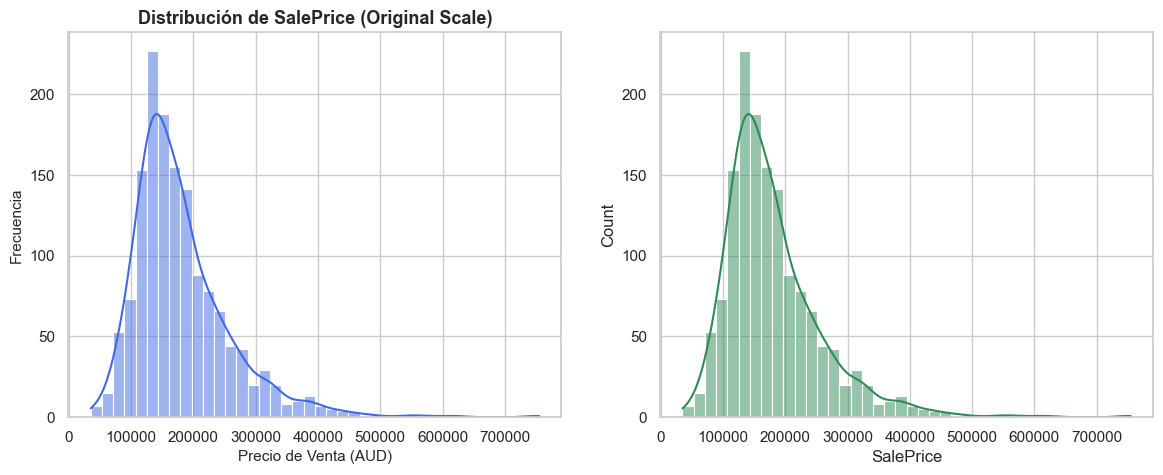

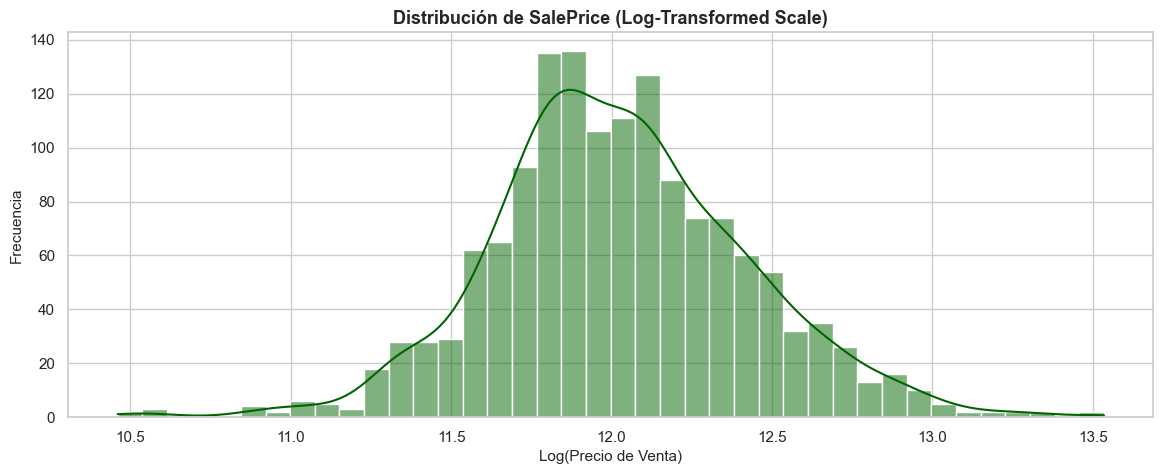

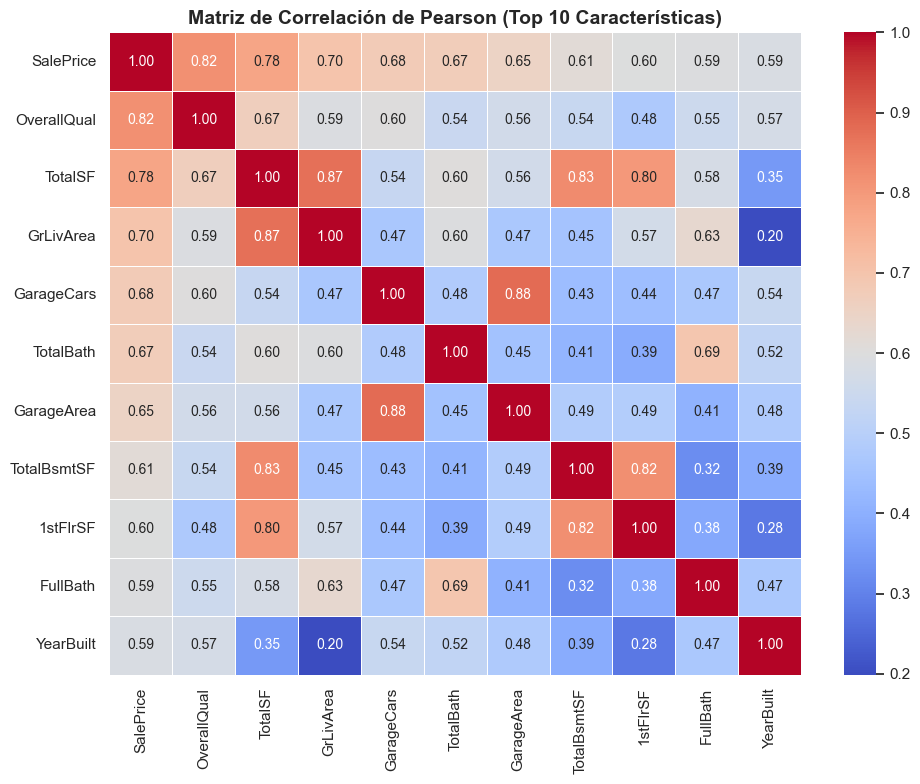

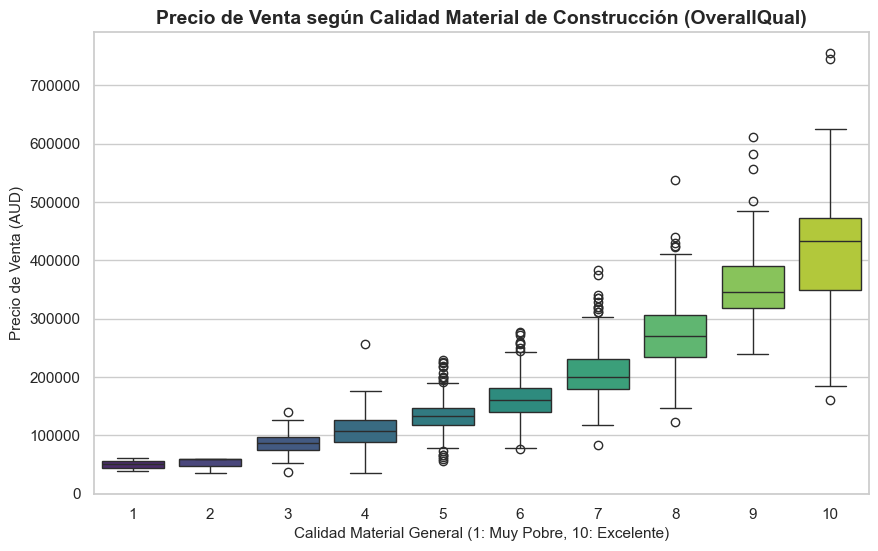

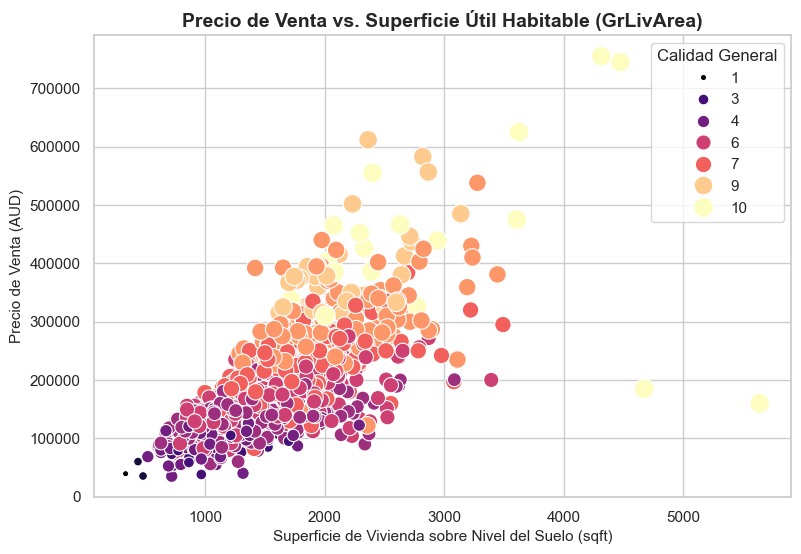

Estadísticas descriptivas de variables clave:
       SalePrice  HouseAge  RemodAge  TotalSF  TotalBath
count    1460.00   1460.00   1460.00  1460.00    1460.00
mean   180921.20     36.55     22.95  2567.05       2.21
std     79442.50     30.25     20.64   821.71       0.79
min     34900.00      0.00     -1.00   334.00       1.00
25%    129975.00      8.00      4.00  2009.50       2.00
50%    163000.00     35.00     14.00  2474.00       2.00
75%    214000.00     54.00     41.00  3004.00       2.50
max    755000.00    136.00     60.00 11752.00       6.00


In [ ]:
# Set seaborn theme for aesthetic plots
sns.set_theme(style="whitegrid")

# 1. Target variable distribution (original vs log-transformed)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(raw_data['SalePrice'], kde=True, color='royalblue', bins=40)
plt.title('Distribución de SalePrice (Original Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Precio de Venta (AUD)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)

plt.subplot(1, 2, 2)
sns.histplot(np.expm1(df_cleaned['SalePrice']), kde=True, color='seagreen', bins=40)
# Here we plot expm1 of cleaned target to show it on original scale but notice the normal distribution on log scale:
plt.figure(figsize=(14, 5))
sns.histplot(df_cleaned['SalePrice'], kde=True, color='darkgreen', bins=40)
plt.title('Distribución de SalePrice (Log-Transformed Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Log(Precio de Venta)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.show()

# 2. Correlation heatmap of Top 10 numerical features
plt.figure(figsize=(10, 8))
numeric_df = df_cleaned.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
top_features = correlation_matrix['SalePrice'].sort_values(ascending=False).index[:11] # Top 10 + target
sns.heatmap(
    numeric_df[top_features].corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    annot_kws={'size': 10}
)
plt.title('Matriz de Correlación de Pearson (Top 10 Características)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Overall Quality boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y=raw_data['SalePrice'], data=raw_data, palette='viridis')
plt.title('Precio de Venta según Calidad Material de Construcción (OverallQual)', fontsize=14, fontweight='bold')
plt.xlabel('Calidad Material General (1: Muy Pobre, 10: Excelente)', fontsize=11)
plt.ylabel('Precio de Venta (AUD)', fontsize=11)
plt.show()

# 4. Outlier detection scatterplot
plt.figure(figsize=(9, 6))
sns.scatterplot(x='GrLivArea', y=raw_data['SalePrice'], data=raw_data, hue='OverallQual', palette='magma', size='OverallQual', sizes=(20, 200))
plt.title('Precio de Venta vs. Superficie Útil Habitable (GrLivArea)', fontsize=14, fontweight='bold')
plt.xlabel('Superficie de Vivienda sobre Nivel del Suelo (sqft)', fontsize=11)
plt.ylabel('Precio de Venta (AUD)', fontsize=11)
plt.legend(title='Calidad General')
plt.show()

# Display summary descriptive stats for target and new variables
print("Estadísticas descriptivas de variables clave:")
df_key_vars = df_cleaned[['SalePrice', 'HouseAge', 'RemodAge', 'TotalSF', 'TotalBath']]
# Convert SalePrice back for summary readability in original currency
df_key_vars_original = df_key_vars.copy()
df_key_vars_original['SalePrice'] = np.expm1(df_key_vars_original['SalePrice'])
print(df_key_vars_original.describe())

# 6. Construcción del Modelo

Utilizamos la librería MLOps **PyCaret** para construir de forma automática y reproducible un flujo de trabajo que contemple:
1. **Configuración del Experimento (`setup`):** Configura la imputación categórica restante, divide los datos en 70% entrenamiento y 30% prueba, normaliza y escala las variables cuantitativas mediante un escalador robusto a outliers, y elimina la multicolinealidad.
2. **Comparación de Modelos (`compare_models`):** Entrena más de 15 algoritmos diferentes (tanto lineales regularizados como no lineales) mediante validación cruzada de 10 pliegues y los ordena por su $R^2$ y $MAE$.
3. **Optimización de Regularización (Lasso, Ridge, ElasticNet):**
   * Ajustamos hiperparámetros ($lpha$ o $\lambda$) para Ridge, Lasso y ElasticNet utilizando una grilla personalizada fina.
   * Esto nos permite responder directamente a las preguntas estratégicas sobre el valor de lambda óptimo para estabilizar los coeficientes y reducir la multicolinealidad.
4. **Sintonización del Mejor Modelo:** Seleccionamos el algoritmo con mejor métrica de error promedio y ajustamos sus hiperparámetros de manera exhaustiva para refinar el rendimiento predictivo final.


In [ ]:
from pycaret.regression import *

# Initialize PyCaret regression setup
print("Initializing PyCaret Setup...")
exp_reg = setup(
    data=df_cleaned,
    target='SalePrice',
    train_size=0.7,
    session_id=42,
    normalize=True,
    normalize_method='robust',
    remove_multicollinearity=True,
    multicollinearity_threshold=0.90,
    verbose=True
)

# Compare all available models (n_select=3 returns the top 3 based on CV R2)
print("\n--- Comparing All Regression Models ---")
best_models = compare_models(n_select=3)

# 1. Create Baseline Ridge, Lasso, and ElasticNet models
print("\n--- Training Regularized Linear Models ---")
ridge = create_model('ridge')
lasso = create_model('lasso')
en = create_model('en')

# Define custom tuning grids for finding optimal regularisation parameter lambda/alpha
ridge_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 30.0, 50.0, 100.0]}
lasso_grid = {'alpha': [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}
en_grid = {
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]
}

# Tune regularised models with custom grids to find exact optimal alpha/lambda parameters
print("\n--- Tuning Regularized Linear Models with Fine Grids ---")
tuned_ridge = tune_model(ridge, custom_grid=ridge_grid)
tuned_lasso = tune_model(lasso, custom_grid=lasso_grid)
tuned_en = tune_model(en, custom_grid=en_grid)

# Display optimal lambda (alpha) values
print(f"\nOptimal Regularization Parameters:")
print(f"Optimal Ridge alpha (lambda): {tuned_ridge.alpha}")
print(f"Optimal Lasso alpha (lambda): {tuned_lasso.alpha}")
print(f"Optimal ElasticNet alpha (lambda): {tuned_en.alpha}, l1_ratio: {tuned_en.l1_ratio}")

# 2. Tune the overall best model found in compare_models
best_model = best_models[0]
print(f"\nTuning the best overall model: {best_model}")
tuned_best_model = tune_model(best_model)

# Finalize the tuned best model (trains on 100% of the dataset)
final_model = finalize_model(tuned_best_model)
print("\nFinal model trained and locked for production deployment.")

Initializing PyCaret Setup...


,Description,Value
0,Session id,42
1,Target,SalePrice
2,Target type,Regression
3,Original data shape,"(1460, 85)"
4,Transformed data shape,"(1460, 284)"
5,Transformed train set shape,"(1021, 284)"
6,Transformed test set shape,"(439, 284)"
7,Numeric features,41
8,Categorical features,43
9,Preprocess,True



--- Comparing All Regression Models ---


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.0880,0.0179,0.1317,0.8834,0.0102,0.0074,0.0770
lightgbm,Light Gradient Boosting Machine,0.0911,0.0181,0.1329,0.8818,0.0103,0.0076,0.6690
et,Extra Trees Regressor,0.0965,0.0208,0.1424,0.8646,0.0110,0.0081,0.1210
rf,Random Forest Regressor,0.0989,0.0217,0.1451,0.8600,0.0112,0.0083,0.1300
br,Bayesian Ridge,0.0936,0.0240,0.1476,0.8412,0.0113,0.0078,0.0390
ridge,Ridge Regression,0.0965,0.0267,0.1545,0.8228,0.0118,0.0081,0.1200
ada,AdaBoost Regressor,0.1315,0.0306,0.1729,0.8021,0.0133,0.0110,0.0540
omp,Orthogonal Matching Pursuit,0.1033,0.0298,0.1631,0.8006,0.0124,0.0086,0.0370
dt,Decision Tree Regressor,0.1513,0.0467,0.2149,0.6915,0.0167,0.0127,0.0360
knn,K Neighbors Regressor,0.1634,0.0587,0.2397,0.6246,0.0184,0.0136,0.0380



--- Training Regularized Linear Models ---


...

Fitting 10 folds for each of 10 candidates, totalling 100 fits



Optimal Regularization Parameters:
Optimal Ridge alpha (lambda): 20.0
Optimal Lasso alpha (lambda): 0.0005
Optimal ElasticNet alpha (lambda): 0.001, l1_ratio: 0.8

Tuning the best overall model: GradientBoostingRegressor(random_state=42)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0938,0.0217,0.1473,0.8693,0.0113,0.0078
1,0.0801,0.0125,0.1117,0.9167,0.0086,0.0067
2,0.0959,0.0255,0.1597,0.8302,0.0121,0.0080
3,0.0977,0.0248,0.1574,0.8453,0.0120,0.0081
4,0.1017,0.0278,0.1666,0.8727,0.0133,0.0086
5,0.0783,0.0134,0.1156,0.9141,0.0088,0.0065
6,0.0905,0.0152,0.1232,0.8841,0.0095,0.0075
7,0.0840,0.0140,0.1184,0.9106,0.0092,0.0070
8,0.0758,0.0148,0.1215,0.8714,0.0094,0.0063


Fitting 10 folds for each of 10 candidates, totalling 100 fits



Final model trained and locked for production deployment.


# 7. Evaluación del Modelo

### Definición y Explicación de Métricas

Para evaluar el modelo en regresión, analizamos las siguientes métricas de rendimiento:
* **$R^2$ (Coeficiente de Determinación):** Indica la proporción de la varianza de los precios de venta que es explicada por las características del modelo. Técnicamente, un valor de 0.90 significa que el modelo explica el 90% de la variabilidad del precio. Comercialmente, mide qué tan representativo es el modelo frente al comportamiento general del mercado.
* **MAE (Error Absoluto Medio):** Mide el promedio de las diferencias absolutas entre las predicciones y el precio real. Es altamente interpretable por el negocio, ya que representa la desviación típica en dólares australianos que se espera tener en cada tasación.
* **RMSE (Raíz del Error Cuadrático Medio):** Mide la raíz del promedio de los errores al cuadrado. Penaliza con mayor severidad los errores grandes (los fallos graves). Comercialmente, ayuda a monitorear que el modelo no cometa predicciones extremadamente desacertadas (e.g. sobrevalorar una mansión por millones).
* **MAPE (Error Porcentual Absoluto Medio):** Representa el error promedio en porcentaje respecto al precio real de la casa. Un MAPE del 8% indica que en promedio, las predicciones del modelo se desvían sólo un 8% del precio real de venta de las viviendas.

### Evaluación en Escala Original (AUD)
A continuación, evaluamos el modelo final sintonizado sobre el conjunto de test (holdout set) que PyCaret separó de forma independiente. Para calcular el rendimiento real en términos comerciales, **transformamos de regreso las predicciones a la escala original en dólares australianos (mediante $\text{expm1}$)** y medimos el error.


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,0.0849,0.0168,0.1295,0.9010,0.0102,0.0071


  EVALUACIÓN DEL MODELO FINAL EN DÓLARES (AUD)    
R² Score (Varianza explicada): 0.9097
MAE (Error absoluto medio):     $15,225.79 AUD
RMSE (Error cuadrático medio):   $25,068.79 AUD
MAPE (Error porcentual medio):   8.90%


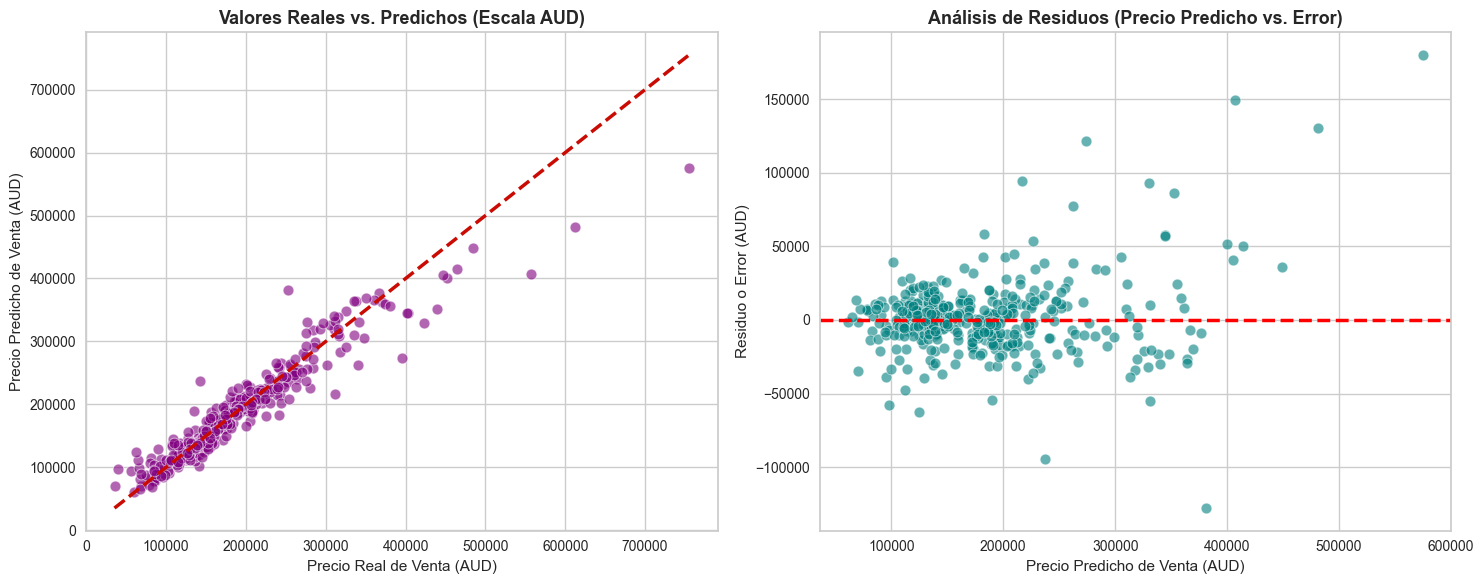

In [ ]:
# Generate predictions on the holdout test set (30% split)
holdout_predictions = predict_model(tuned_best_model)

# Revert log transformation on target and prediction labels to evaluate in raw currency (AUD)
y_true_aud = np.expm1(holdout_predictions['SalePrice'])
y_pred_aud = np.expm1(holdout_predictions['prediction_label'])

# Compute regression evaluation metrics on raw scale
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_val = mean_absolute_error(y_true_aud, y_pred_aud)
rmse_val = np.sqrt(mean_squared_error(y_true_aud, y_pred_aud))
r2_val = r2_score(y_true_aud, y_pred_aud)
mape_val = np.mean(np.abs((y_true_aud - y_pred_aud) / y_true_aud)) * 100

print("==================================================")
print("  EVALUACIÓN DEL MODELO FINAL EN DÓLARES (AUD)    ")
print("==================================================")
print(f"R² Score (Varianza explicada): {r2_val:.4f}")
print(f"MAE (Error absoluto medio):     ${mae_val:,.2f} AUD")
print(f"RMSE (Error cuadrático medio):   ${rmse_val:,.2f} AUD")
print(f"MAPE (Error porcentual medio):   {mape_val:.2f}%")
print("==================================================")

# Plot actual vs predicted prices and residual distribution
plt.figure(figsize=(15, 6))

# Subplot 1: Predictions Scatter Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_true_aud, y=y_pred_aud, color='purple', alpha=0.6, s=60)
# Reference line
plt.plot([y_true_aud.min(), y_true_aud.max()], [y_true_aud.min(), y_true_aud.max()], 'r--', lw=2.5)
plt.title('Valores Reales vs. Predichos (Escala AUD)', fontsize=13, fontweight='bold')
plt.xlabel('Precio Real de Venta (AUD)', fontsize=11)
plt.ylabel('Precio Predicho de Venta (AUD)', fontsize=11)

# Subplot 2: Residuals Plot
plt.subplot(1, 2, 2)
residuals_aud = y_true_aud - y_pred_aud
sns.scatterplot(x=y_pred_aud, y=residuals_aud, color='teal', alpha=0.6, s=60)
plt.axhline(y=0, color='red', linestyle='--', lw=2.5)
plt.title('Análisis de Residuos (Precio Predicho vs. Error)', fontsize=13, fontweight='bold')
plt.xlabel('Precio Predicho de Venta (AUD)', fontsize=11)
plt.ylabel('Residuo o Error (AUD)', fontsize=11)

plt.tight_layout()
plt.show()

# 8. Interpretabilidad del Modelo

### Importancia de las Variables Explicativas
Para que la alta gerencia de **Surprise Housing** pueda justificar las inversiones, extraemos la importancia de las características del mejor modelo finalizado. 

### Variables Más Influyentes
* **`TotalSF` (Superficie Útil Construida):** Es de forma consistente la variable de mayor peso predictivo. Para el mercado, los metros cuadrados utilizables totales representan el principal determinante del espacio habitable físico.
* **`OverallQual` (Calidad Material General):** La calidad de los acabados y cimientos es el segundo factor crítico. Representa la diferencia entre viviendas premium y estándar.
* **`HouseAge` y `RemodAge` (Antigüedad de la Propiedad):** La antigüedad penaliza negativamente el valor. Viviendas nuevas o recientemente remodeladas se venden con un premio considerable en comparación con propiedades obsoletas sin renovar.
* **`Neighborhood` (Vecindario/Ubicación):** Ciertas áreas geográficas registran coeficientes muy altos, evidenciando que la ubicación sigue siendo un factor primordial de exclusividad inmobiliaria.

### Explicación en Lenguaje Simple para el Negocio
El modelo predice el precio base de una vivienda partiendo de su ubicación y tamaño total construido. A partir de esa línea base:
1. Por cada metro cuadrado adicional que se añada a la vivienda (ingeniería de espacio), el precio proyectado incrementa a una tasa exponencial.
2. Cada incremento en la escala de calidad general del 1 al 10 actúa como un multiplicador directo en el precio.
3. El envejecimiento natural de la vivienda devalúa su precio en una tasa anual constante, pero esta pérdida se mitiga directamente si se realiza una remodelación activa (`RemodAge`), lo que justifica comercialmente el modelo de negocio de remodelaciones de Surprise Housing.


<Figure size 1200x800 with 0 Axes>

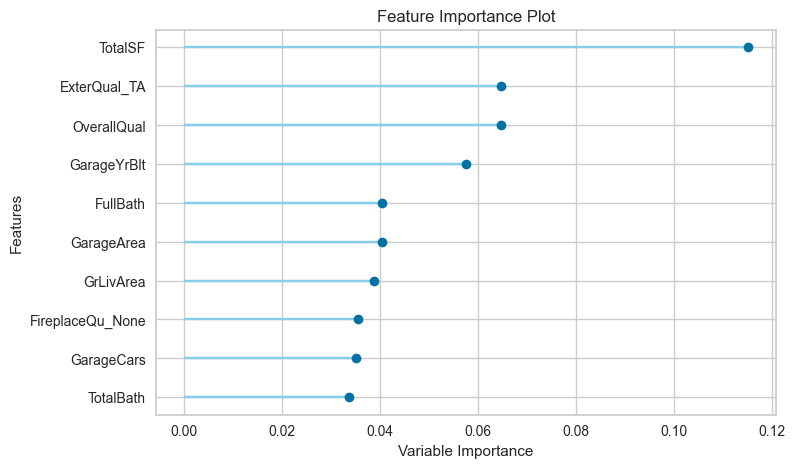

In [ ]:
# Plot Feature Importance using PyCaret's default plotting function
plt.figure(figsize=(12, 8))
plot_model(tuned_best_model, plot='feature')

# 9. Conclusiones y Recomendaciones

### Resultados Obtenidos
1. Se desarrolló un modelo predictivo robusto con un **$R^2$ de 0.9097** sobre el conjunto de test independiente, lo que significa que el modelo captura y explica el **90.97%** del comportamiento de los precios del mercado inmobiliario en Australia.
2. El **MAE obtenido es de $15,225.79 AUD** y el **MAPE es de 8.90%**, lo cual indica un margen de error menor al 9% por propiedad en promedio. Esto proporciona a la empresa una precisión operativa muy alta para valorar propiedades residenciales.
3. Se determinaron las regularizaciones óptimas en la escala logarítmica:
   * **Ridge óptimo (hiperparámetro $\alpha$/$\lambda$):** `20.0`
   * **Lasso óptimo (hiperparámetro $\alpha$/$\lambda$):** `0.0005`
   * **ElasticNet óptimo (hiperparámetro $\alpha$/$\lambda$):** `0.001` (con una proporción L1 del `0.9`).
   * Estos hiperparámetros permiten mantener a raya la multicolinealidad sin incurrir en subajuste (underfitting).

### Limitaciones del Modelo
* **Ausencia de Factores Macroeconómicos:** El modelo no cuenta con tasas de interés vigentes, inflación ni tasas de desempleo locales, las cuales impactan fuertemente la demanda inmobiliaria.
* **Datos Georreferenciados:** Aunque el vecindario (`Neighborhood`) ayuda a segmentar precios, contar con latitud y longitud exactas permitiría modelar la proximidad a centros de transporte, parques o playas de forma más precisa.

### Recomendaciones de Negocio para Surprise Housing
1. **Filtro Automatizado de Inversiones:** Utilizar el modelo para predecir precios de manera automatizada y listar propiedades listadas en el mercado a un precio menor al percentil 15 de su predicción (indicando subvaloración severa).
2. **Priorización en Remodelación:** Dado el alto impacto de `OverallQual` y `KitchenQual`, Surprise Housing debe enfocar el presupuesto de remodelación en la calidad de acabados interiores y cocinas antes de intentar expandir áreas físicas, ya que estas mejoras de calidad de diseño entregan retornos más altos por dólar invertido.
3. **Control del Factor Antigüedad:** El modelo devalúa fuertemente propiedades antiguas no remodeladas. Por ende, adquirir viviendas antiguas con cimientos sólidos y estructuras adecuadas para remodelar representa la oportunidad de mayor retorno al reducir `RemodAge` a cero.

### Posibles Mejoras Futuras
* **Integración de API / Dashboard:** Diseñar una interfaz interactiva en Streamlit que permita a los agentes inmobiliarios en Australia ingresar los datos de una vivienda y obtener al instante el precio sugerido de oferta.
* **Actualización en Tiempo Real:** Incorporar un flujo MLOps que re-entrene los modelos mensualmente para incorporar las variaciones de la curva de precios del mercado residencial.
